In [1]:
# Install libraries (run this first in Colab)
!pip install seaborn matplotlib pandas numpy scipy -q

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
# Load Titanic dataset directly from Seaborn
df = sns.load_dataset("titanic")

print(f"📦 Dataset Loaded!")
print(f"   Shape : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\n🔢 First 5 Rows:")
df.head()

📦 Dataset Loaded!
   Shape : 891 rows × 15 columns

🔢 First 5 Rows:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
print("📋 Column Data Types:")
print(df.dtypes)

print("\n\n❌ Missing Values:")
missing = df.isnull().sum()
print(missing[missing > 0])

print("\n\n📊 Statistical Summary:")
df[["age", "fare", "sibsp", "parch"]].describe().round(2)

📋 Column Data Types:
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object


❌ Missing Values:
age            177
embarked         2
deck           688
embark_town      2
dtype: int64


📊 Statistical Summary:


,age,fare,sibsp,parch
count,714.00,891.00,891.00,891.00
mean,29.70,32.20,0.52,0.38
std,14.53,49.69,1.10,0.81
min,0.42,0.00,0.00,0.00
25%,20.12,7.91,0.00,0.00
50%,28.00,14.45,0.00,0.00
75%,38.00,31.00,1.00,0.00
max,80.00,512.33,8.00,6.00


In [4]:
# Create Age Group column
df["age_group"] = pd.cut(
    df["age"],
    bins  = [0, 12, 18, 35, 60, 100],
    labels= ["Child\n(0–12)", "Teen\n(13–18)", "Young Adult\n(19–35)",
             "Middle Age\n(36–60)", "Senior\n(60+)"]
)

# Create Family Size column
df["family_size"] = df["sibsp"] + df["parch"] + 1

print("✅ New columns created:")
print("   → age_group")
print("   → family_size")
print(f"\n   Family size range : {df['family_size'].min()} to {df['family_size'].max()}")
print(f"   Age groups        : {list(df['age_group'].cat.categories)}")

✅ New columns created:
   → age_group
   → family_size

   Family size range : 1 to 11
   Age groups        : ['Child\n(0–12)', 'Teen\n(13–18)', 'Young Adult\n(19–35)', 'Middle Age\n(36–60)', 'Senior\n(60+)']


In [5]:
print("🎯 Key Survival Statistics")
print("=" * 40)
print(f"  Total Passengers      : {len(df)}")
print(f"  Survived              : {df['survived'].sum()}")
print(f"  Did Not Survive       : {(df['survived']==0).sum()}")
print(f"  Overall Survival Rate : {df['survived'].mean()*100:.2f}%")

print("\n  Survival by Sex:")
print(df.groupby("sex")["survived"].mean().mul(100).round(2).rename("Rate (%)"))

print("\n  Survival by Class:")
print(df.groupby("pclass")["survived"].mean().mul(100).round(2).rename("Rate (%)"))

print("\n  Survival by Embarkation:")
print(df.groupby("embark_town")["survived"].mean().mul(100).round(2).rename("Rate (%)"))

🎯 Key Survival Statistics
  Total Passengers      : 891
  Survived              : 342
  Did Not Survive       : 549
  Overall Survival Rate : 38.38%

  Survival by Sex:
sex
female    74.20
male      18.89
Name: Rate (%), dtype: float64

  Survival by Class:
pclass
1    62.96
2    47.28
3    24.24
Name: Rate (%), dtype: float64

  Survival by Embarkation:
embark_town
Cherbourg      55.36
Queenstown     38.96
Southampton    33.70
Name: Rate (%), dtype: float64


In [6]:
# Colors
SURVIVE_COLORS = ["#E74C3C", "#2ECC71"]   # Red = No, Green = Yes
CLASS_COLORS   = ["#F1C40F", "#3498DB", "#95A5A6"]
BG_COLOR       = "#F8F9FA"
DARK           = "#1A1A2E"

# Global style
plt.rcParams.update({
    "font.family"      : "DejaVu Sans",
    "axes.facecolor"   : BG_COLOR,
    "figure.facecolor" : "white",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.labelcolor"  : DARK,
    "xtick.color"      : DARK,
    "ytick.color"      : DARK,
    "axes.titleweight" : "bold",
    "axes.titlesize"   : 12,
    "axes.titlepad"    : 10,
})

print("✅ Color palette & style configured!")
print(f"   Survived color    : {SURVIVE_COLORS[1]}  (Green)")
print(f"   Not survived color: {SURVIVE_COLORS[0]}  (Red)")

✅ Color palette & style configured!
   Survived color    : #2ECC71  (Green)
   Not survived color: #E74C3C  (Red)


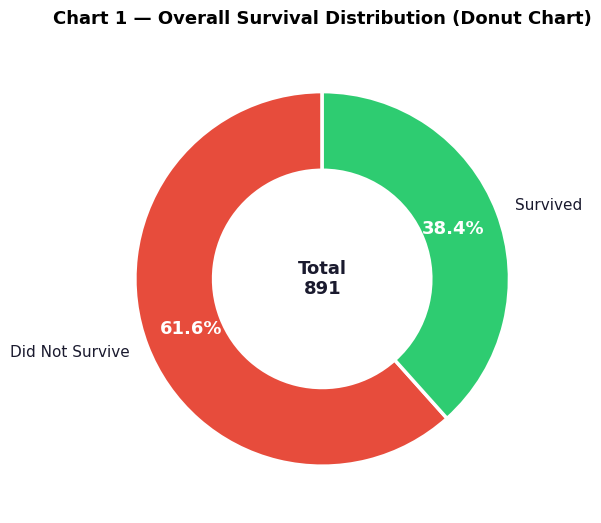

✅ Chart 1 saved!


In [7]:
fig, ax = plt.subplots(figsize=(6, 6), facecolor="white")

counts = df["survived"].value_counts().sort_index()
wedge_props = dict(width=0.42, edgecolor="white", linewidth=2.5)

wedges, texts, autotexts = ax.pie(
    counts,
    labels      = ["Did Not Survive", "Survived"],
    colors      = SURVIVE_COLORS,
    autopct     = "%1.1f%%",
    startangle  = 90,
    wedgeprops  = wedge_props,
    textprops   = {"fontsize": 11, "color": DARK},
    pctdistance = 0.75
)
for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight("bold")
    at.set_color("white")

ax.annotate(f"Total\n{len(df)}", xy=(0,0),
            ha="center", va="center",
            fontsize=13, fontweight="bold", color=DARK)

ax.set_title("Chart 1 — Overall Survival Distribution (Donut Chart)",
             fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("chart1_donut.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 1 saved!")

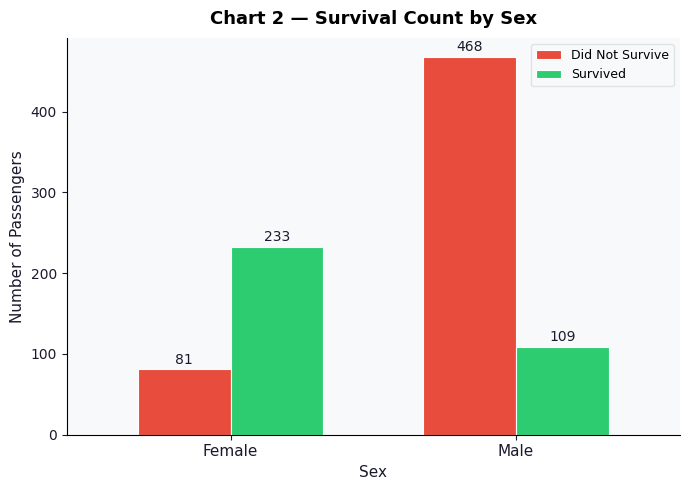

✅ Chart 2 saved!


In [8]:
fig, ax = plt.subplots(figsize=(7, 5), facecolor="white")
ax.set_facecolor(BG_COLOR)
ax.spines[["top","right"]].set_visible(False)

sex_data = df.groupby(["sex", "survived"]).size().unstack()
sex_data.columns = ["Did Not Survive", "Survived"]
sex_data.plot(kind="bar", ax=ax, color=SURVIVE_COLORS,
              edgecolor="white", linewidth=0.8, width=0.65)

ax.set_title("Chart 2 — Survival Count by Sex", fontsize=13, fontweight="bold")
ax.set_xlabel("Sex", fontsize=11)
ax.set_ylabel("Number of Passengers", fontsize=11)
ax.set_xticklabels(["Female", "Male"], rotation=0, fontsize=11)
ax.legend(fontsize=9, framealpha=0.5)

for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 3,
            str(int(bar.get_height())),
            ha="center", va="bottom", fontsize=10, color=DARK)

plt.tight_layout()
plt.savefig("chart2_sex_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 2 saved!")

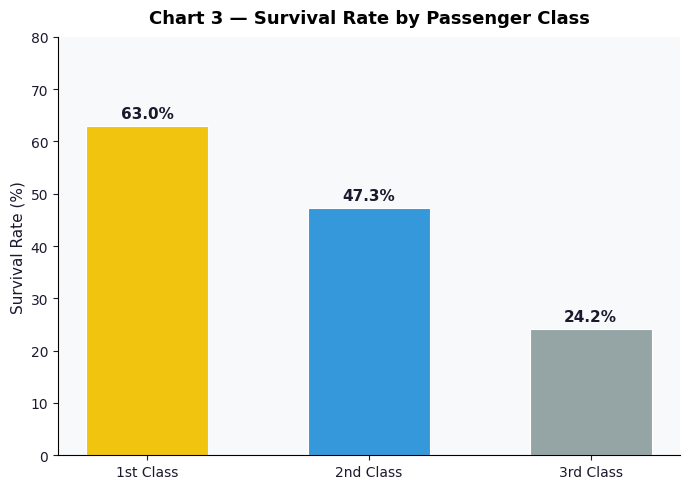

✅ Chart 3 saved!


In [9]:
fig, ax = plt.subplots(figsize=(7, 5), facecolor="white")
ax.set_facecolor(BG_COLOR)
ax.spines[["top","right"]].set_visible(False)

pclass_rate = df.groupby("pclass")["survived"].mean() * 100
bars = ax.bar(["1st Class", "2nd Class", "3rd Class"],
              pclass_rate.values,
              color=CLASS_COLORS, edgecolor="white",
              linewidth=0.8, width=0.55)

ax.set_title("Chart 3 — Survival Rate by Passenger Class", fontsize=13, fontweight="bold")
ax.set_ylabel("Survival Rate (%)", fontsize=11)
ax.set_ylim(0, 80)

for bar, val in zip(bars, pclass_rate.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1.5,
            f"{val:.1f}%",
            ha="center", fontsize=11, fontweight="bold", color=DARK)

plt.tight_layout()
plt.savefig("chart3_pclass_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 3 saved!")

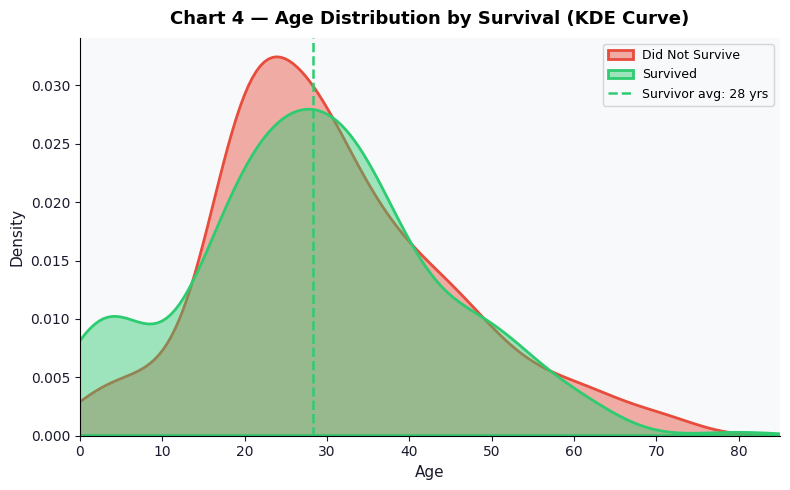

✅ Chart 4 saved!


In [10]:
fig, ax = plt.subplots(figsize=(8, 5), facecolor="white")
ax.set_facecolor(BG_COLOR)
ax.spines[["top","right"]].set_visible(False)

for val, label, color in zip([0,1], ["Did Not Survive","Survived"], SURVIVE_COLORS):
    sns.kdeplot(df[df["survived"]==val]["age"].dropna(),
                ax=ax, fill=True, alpha=0.45,
                color=color, label=label, linewidth=2)

avg_surv = df[df["survived"]==1]["age"].mean()
ax.axvline(avg_surv, color="#2ECC71", linestyle="--",
           linewidth=1.8, label=f"Survivor avg: {avg_surv:.0f} yrs")

ax.set_title("Chart 4 — Age Distribution by Survival (KDE Curve)", fontsize=13, fontweight="bold")
ax.set_xlabel("Age", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_xlim(0, 85)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("chart4_age_kde.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 4 saved!")

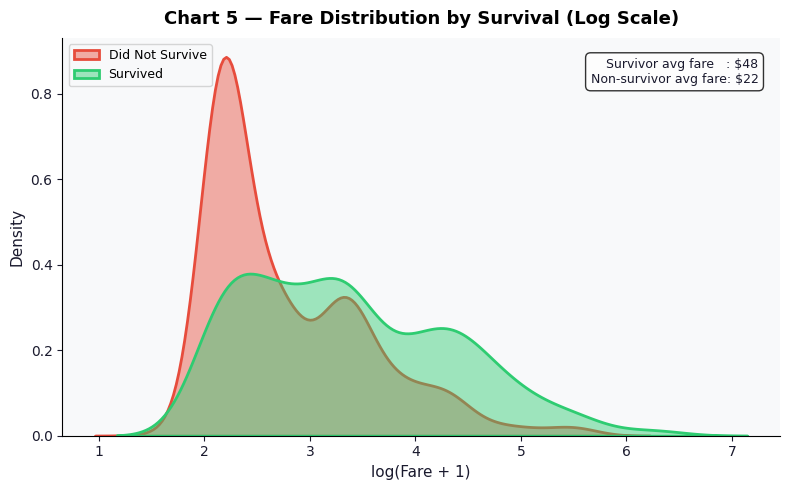

✅ Chart 5 saved!


In [11]:
fig, ax = plt.subplots(figsize=(8, 5), facecolor="white")
ax.set_facecolor(BG_COLOR)
ax.spines[["top","right"]].set_visible(False)

for val, label, color in zip([0,1], ["Did Not Survive","Survived"], SURVIVE_COLORS):
    data = df[df["survived"]==val]["fare"].dropna()
    data = data[data > 0]
    sns.kdeplot(np.log1p(data), ax=ax, fill=True,
                alpha=0.45, color=color, label=label, linewidth=2)

surv_avg   = df[df["survived"]==1]["fare"].mean()
nosurv_avg = df[df["survived"]==0]["fare"].mean()
ax.text(0.97, 0.95,
        f"Survivor avg fare   : ${surv_avg:.0f}\nNon-survivor avg fare: ${nosurv_avg:.0f}",
        transform=ax.transAxes, ha="right", va="top", fontsize=9, color=DARK,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.8))

ax.set_title("Chart 5 — Fare Distribution by Survival (Log Scale)", fontsize=13, fontweight="bold")
ax.set_xlabel("log(Fare + 1)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("chart5_fare_kde.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 5 saved!")

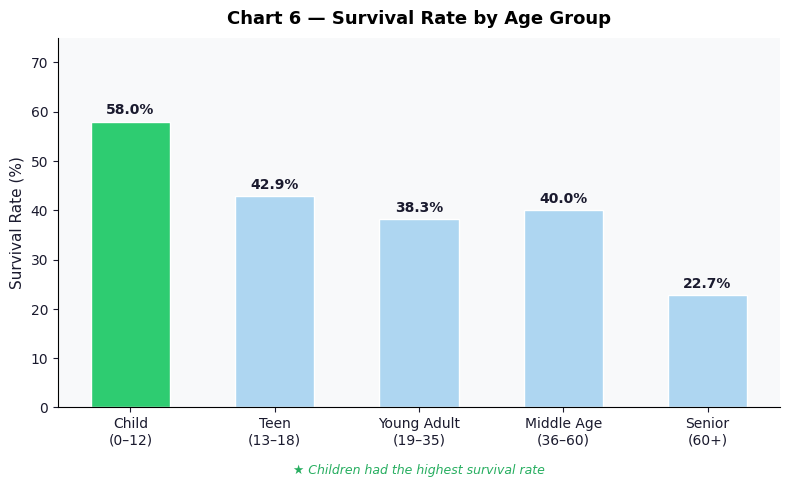

✅ Chart 6 saved!


In [12]:
fig, ax = plt.subplots(figsize=(8, 5), facecolor="white")
ax.set_facecolor(BG_COLOR)
ax.spines[["top","right"]].set_visible(False)

age_rate   = df.groupby("age_group", observed=True)["survived"].mean() * 100
max_val    = age_rate.max()
bar_colors = ["#2ECC71" if v == max_val else "#AED6F1" for v in age_rate.values]

bars = ax.bar(age_rate.index, age_rate.values,
              color=bar_colors, edgecolor="white", width=0.55)

ax.set_title("Chart 6 — Survival Rate by Age Group", fontsize=13, fontweight="bold")
ax.set_ylabel("Survival Rate (%)", fontsize=11)
ax.set_ylim(0, 75)

for bar, val in zip(bars, age_rate.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1.5,
            f"{val:.1f}%",
            ha="center", fontsize=10, fontweight="bold", color=DARK)

ax.text(0.5, -0.18, "★ Children had the highest survival rate",
        transform=ax.transAxes, ha="center",
        fontsize=9, color="#27AE60", style="italic")

plt.tight_layout()
plt.savefig("chart6_agegroup_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 6 saved!")

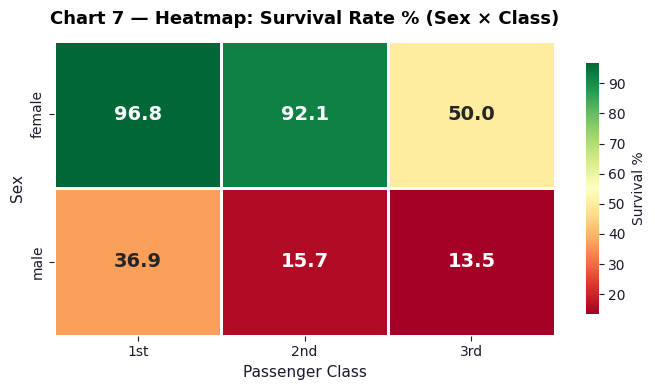

✅ Chart 7 saved!


In [13]:
fig, ax = plt.subplots(figsize=(7, 4), facecolor="white")

pivot = df.pivot_table("survived", index="sex",
                        columns="pclass", aggfunc="mean") * 100

sns.heatmap(pivot, annot=True, fmt=".1f",
            cmap="RdYlGn", ax=ax,
            linewidths=0.8, linecolor="white",
            cbar_kws={"label": "Survival %", "shrink": 0.85},
            annot_kws={"size": 14, "weight": "bold"})

ax.set_title("Chart 7 — Heatmap: Survival Rate % (Sex × Class)",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Passenger Class", fontsize=11)
ax.set_ylabel("Sex", fontsize=11)
ax.set_xticklabels(["1st", "2nd", "3rd"], rotation=0)

plt.tight_layout()
plt.savefig("chart7_heatmap_sex_class.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 7 saved!")

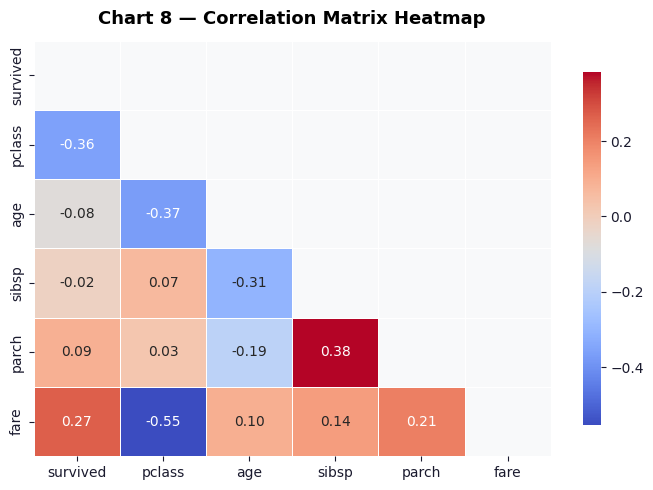

✅ Chart 8 saved!


In [14]:
fig, ax = plt.subplots(figsize=(7, 5), facecolor="white")

corr_df = df[["survived","pclass","age","sibsp","parch","fare"]].dropna().corr()
mask    = np.triu(np.ones_like(corr_df, dtype=bool))

sns.heatmap(corr_df, annot=True, fmt=".2f",
            cmap="coolwarm", ax=ax, mask=mask,
            linewidths=0.5, linecolor="white",
            cbar_kws={"shrink": 0.85},
            annot_kws={"size": 10})

ax.set_title("Chart 8 — Correlation Matrix Heatmap",
             fontsize=13, fontweight="bold", pad=12)

plt.tight_layout()
plt.savefig("chart8_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 8 saved!")

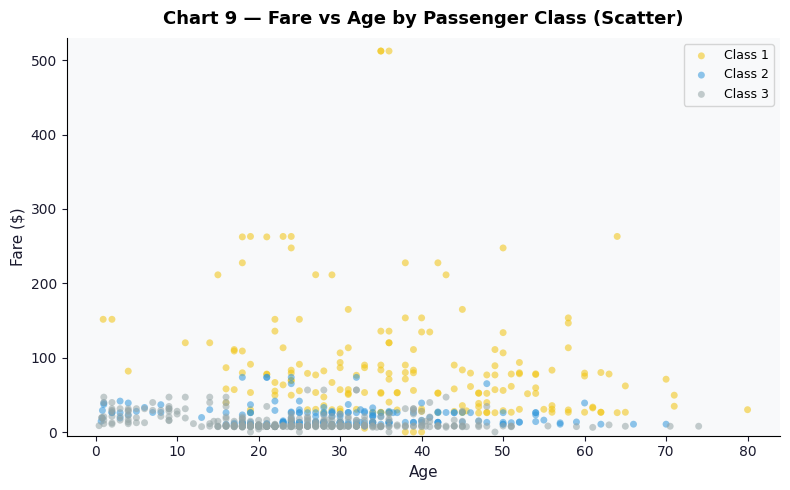

✅ Chart 9 saved!


In [15]:
fig, ax = plt.subplots(figsize=(8, 5), facecolor="white")
ax.set_facecolor(BG_COLOR)
ax.spines[["top","right"]].set_visible(False)

scatter_colors = {1: "#F1C40F", 2: "#3498DB", 3: "#95A5A6"}
for cls in [1, 2, 3]:
    sub = df[df["pclass"] == cls]
    ax.scatter(sub["age"], sub["fare"],
               c=scatter_colors[cls], alpha=0.55, s=25,
               label=f"Class {cls}", edgecolors="none")

ax.set_title("Chart 9 — Fare vs Age by Passenger Class (Scatter)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Age", fontsize=11)
ax.set_ylabel("Fare ($)", fontsize=11)
ax.set_ylim(-5, 530)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("chart9_scatter_fare_age.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 9 saved!")

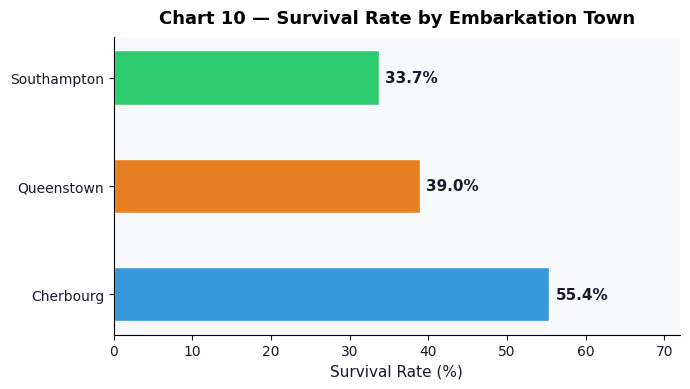

✅ Chart 10 saved!


In [16]:
fig, ax = plt.subplots(figsize=(7, 4), facecolor="white")
ax.set_facecolor(BG_COLOR)
ax.spines[["top","right"]].set_visible(False)

emb_rate   = df.groupby("embark_town")["survived"].mean() * 100
bar_colors = ["#3498DB", "#E67E22", "#2ECC71"]

bars = ax.barh(emb_rate.index, emb_rate.values,
               color=bar_colors, edgecolor="white", height=0.5)

ax.set_title("Chart 10 — Survival Rate by Embarkation Town",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Survival Rate (%)", fontsize=11)
ax.set_xlim(0, 72)

for bar, val in zip(bars, emb_rate.values):
    ax.text(val + 0.8,
            bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%",
            va="center", fontsize=11, fontweight="bold", color=DARK)

plt.tight_layout()
plt.savefig("chart10_embark_hbar.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 10 saved!")

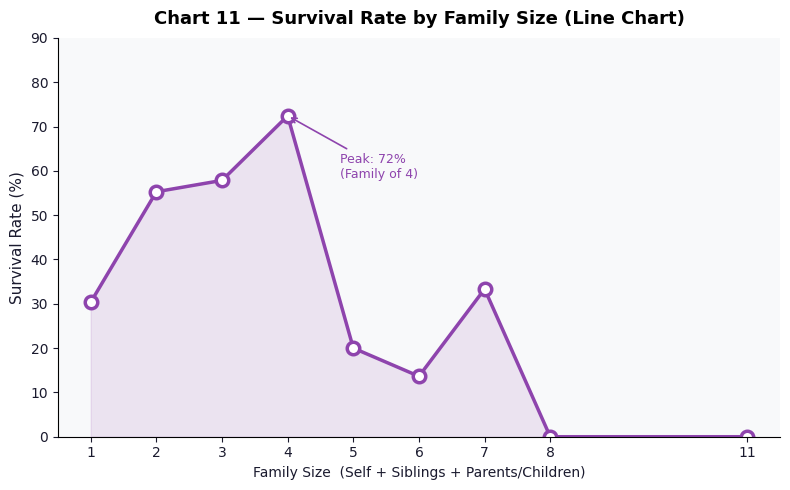

✅ Chart 11 saved!


In [17]:
fig, ax = plt.subplots(figsize=(8, 5), facecolor="white")
ax.set_facecolor(BG_COLOR)
ax.spines[["top","right"]].set_visible(False)

fam_rate = df.groupby("family_size")["survived"].mean() * 100

ax.plot(fam_rate.index, fam_rate.values,
        "o-", color="#8E44AD", linewidth=2.5,
        markersize=9, markerfacecolor="white",
        markeredgecolor="#8E44AD", markeredgewidth=2.5)
ax.fill_between(fam_rate.index, fam_rate.values,
                alpha=0.12, color="#8E44AD")

peak_x = fam_rate.idxmax()
peak_y = fam_rate.max()
ax.annotate(f"Peak: {peak_y:.0f}%\n(Family of {peak_x})",
            xy=(peak_x, peak_y), xytext=(peak_x+0.8, peak_y-14),
            fontsize=9, color="#8E44AD",
            arrowprops=dict(arrowstyle="->", color="#8E44AD", lw=1.2))

ax.set_title("Chart 11 — Survival Rate by Family Size (Line Chart)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Family Size  (Self + Siblings + Parents/Children)", fontsize=10)
ax.set_ylabel("Survival Rate (%)", fontsize=11)
ax.set_xticks(fam_rate.index)
ax.set_ylim(0, 90)

plt.tight_layout()
plt.savefig("chart11_familysize_line.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 11 saved!")

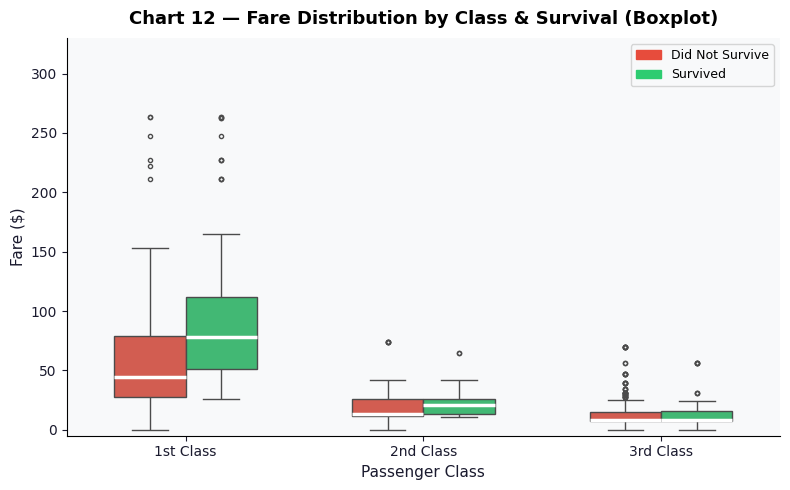

✅ Chart 12 saved!


In [18]:
fig, ax = plt.subplots(figsize=(8, 5), facecolor="white")
ax.set_facecolor(BG_COLOR)
ax.spines[["top","right"]].set_visible(False)

sns.boxplot(data=df, x="pclass", y="fare", hue="survived",
            palette=SURVIVE_COLORS, ax=ax,
            width=0.6, fliersize=3, linewidth=1,
            medianprops={"linewidth": 2.5, "color": "white"})

ax.set_title("Chart 12 — Fare Distribution by Class & Survival (Boxplot)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Passenger Class", fontsize=11)
ax.set_ylabel("Fare ($)", fontsize=11)
ax.set_xticklabels(["1st Class", "2nd Class", "3rd Class"])
ax.set_ylim(-5, 330)

handles = [mpatches.Patch(color=c, label=l)
           for c, l in zip(SURVIVE_COLORS, ["Did Not Survive","Survived"])]
ax.legend(handles=handles, fontsize=9)

plt.tight_layout()
plt.savefig("chart12_boxplot_fare.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 12 saved!")

In [19]:
print("=" * 55)
print("   TASK 3 — FINAL SUMMARY OF KEY INSIGHTS")
print("=" * 55)
print(f"\n  Total Passengers       : {len(df)}")
print(f"  Overall Survival Rate  : {df['survived'].mean()*100:.1f}%")
print(f"  Female Survival Rate   : {df[df['sex']=='female']['survived'].mean()*100:.1f}%")
print(f"  Male Survival Rate     : {df[df['sex']=='male']['survived'].mean()*100:.1f}%")
print(f"  1st Class Survival     : {df[df['pclass']==1]['survived'].mean()*100:.1f}%")
print(f"  2nd Class Survival     : {df[df['pclass']==2]['survived'].mean()*100:.1f}%")
print(f"  3rd Class Survival     : {df[df['pclass']==3]['survived'].mean()*100:.1f}%")
print(f"  Children Survival      : {df[df['age']<=12]['survived'].mean()*100:.1f}%")
print(f"\n  Total Charts Created   : 12")
print(f"  Chart Types            : Donut, Bar, Grouped Bar,")
print(f"                           KDE, Heatmap, Scatter,")
print(f"                           H-Bar, Line, Boxplot")
print("\n" + "=" * 55)
print("   CodeAlpha Internship — Task 3 Complete ✅")
print("=" * 55)

   TASK 3 — FINAL SUMMARY OF KEY INSIGHTS

  Total Passengers       : 891
  Overall Survival Rate  : 38.4%
  Female Survival Rate   : 74.2%
  Male Survival Rate     : 18.9%
  1st Class Survival     : 63.0%
  2nd Class Survival     : 47.3%
  3rd Class Survival     : 24.2%
  Children Survival      : 58.0%

  Total Charts Created   : 12
  Chart Types            : Donut, Bar, Grouped Bar,
                           KDE, Heatmap, Scatter,
                           H-Bar, Line, Boxplot

   CodeAlpha Internship — Task 3 Complete ✅
